[OK] Cargado desde URL: https://media.githubusercontent.com/media/ProyectoHotelesCalifornia/Proyecto_Hoteles_California/refs/heads/main/final_database.csv
Filas: 181,690 | Columnas: 7


,name,county,ratings,text,clean_review,topic,topic_label
0,Four Seasons Hotel Los Angeles at Beverly Hills,Los_Angeles,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",The Four Season LA is probably one of the warm...,four season la probably one warmest friendlies...,2,Great time and location
1,Four Seasons Hotel Los Angeles at Beverly Hills,Los_Angeles,"{'service': 2.0, 'cleanliness': 4.0, 'overall'...",When you stay in a Four Seasons Hotel you have...,four seasons high expectations remarkable stay...,6,Staff
2,Four Seasons Hotel Los Angeles at Beverly Hills,Los_Angeles,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",I spent my birthday this year at the Four Seas...,spent birthday four seasons hotel moment picke...,2,Great time and location


Filas tras filtros: 181,690
Columna de texto usada: clean_review
Reviews válidas: 181,690
[OK] COUNT -> min_df=3 | stopwords=CUSTOM
[OK] TFIDF -> min_df=3 | stopwords=CUSTOM


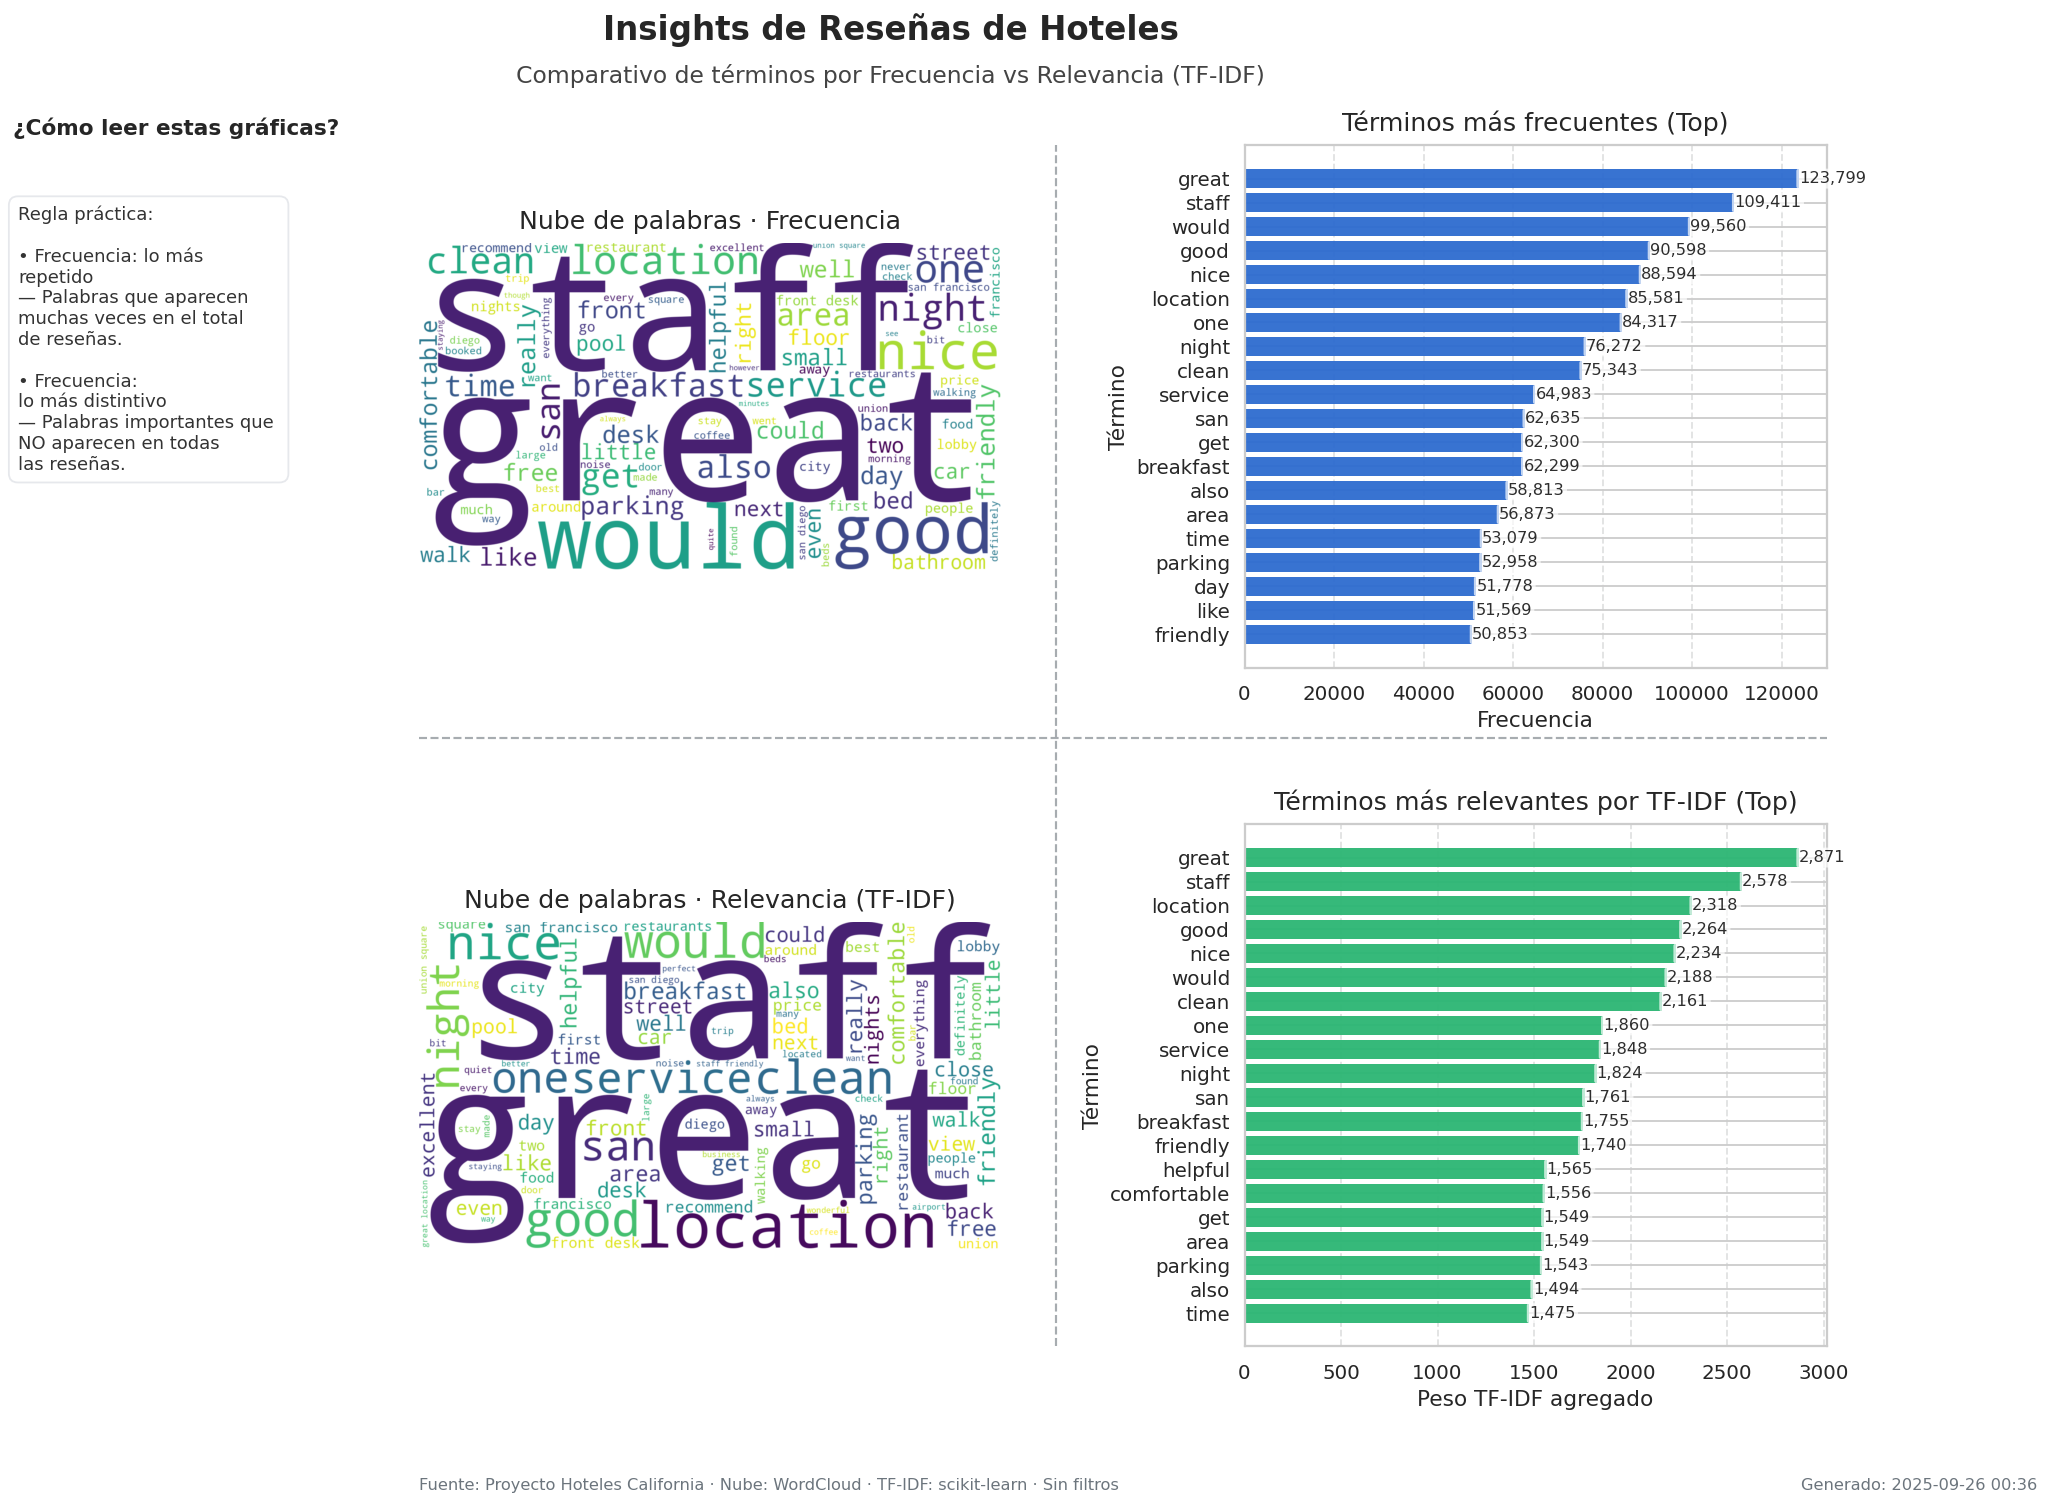

In [ ]:
# ============================================================
# Figura 2×2 "presentación-ready" (Frecuencia / TF-IDF)
# - Panel lateral IZQUIERDO para leyenda/explicación (siempre separado)
# - 4 cuadrantes (nube/barras Frecuencia y TF-IDF) a la derecha
# - Subtítulo separado (y=0.920)
# - Líneas guía (no tapan texto)
# - Exporta PNG (300 dpi) y SVG
# ============================================================

# ---- Instalación sin usar "!" ----
import sys, subprocess
def pip_install(pkgs):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
    except subprocess.CalledProcessError as e:
        print("Error al instalar paquetes:", e)

try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    from sklearn.exceptions import InvalidParameterError
    from wordcloud import WordCloud
    from unidecode import unidecode
    import nltk, re, ast, os, warnings, textwrap, datetime
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle
except Exception:
    pip_install(["pandas","numpy","matplotlib","seaborn","scikit-learn","wordcloud","unidecode","nltk"])
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    try:
        from sklearn.exceptions import InvalidParameterError
    except Exception:
        class InvalidParameterError(Exception): pass
    from wordcloud import WordCloud
    from unidecode import unidecode
    import nltk, re, ast, os, warnings, textwrap, datetime
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")
from IPython.display import display

# ------------------------------
# CARGA ROBUSTA DE STOPWORDS NLTK (con fallback)
# ------------------------------
import os as _os
NLTK_DATA_DIR = _os.path.expanduser("~/nltk_data")
_os.makedirs(NLTK_DATA_DIR, exist_ok=True)
if NLTK_DATA_DIR not in nltk.data.path:
    nltk.data.path.insert(0, NLTK_DATA_DIR)

def _ensure_nltk_stopwords():
    try:
        from nltk.corpus import stopwords as _sw
        _ = _sw.words("english")
        return _sw
    except Exception:
        nltk.download("stopwords", download_dir=NLTK_DATA_DIR, quiet=True)
        from nltk.corpus import stopwords as _sw
        return _sw

try:
    from nltk.corpus import stopwords as _maybe_sw
    _ = _maybe_sw.words("english")
    stopwords = _maybe_sw
except Exception:
    stopwords = _ensure_nltk_stopwords()

def safe_stopwords(lang: str) -> set:
    try:
        return set(stopwords.words(lang))
    except Exception:
        EN_MIN = {
            "the","and","to","of","in","a","is","for","on","with",
            "that","it","this","as","at","by","be","or","an","from","are"
        }
        ES_MIN = {
            "el","la","los","las","de","y","a","en","que",
            "un","una","es","con","por","para","del","al","lo","o"
        }
        return ES_MIN if lang.lower().startswith("span") else EN_MIN

# ============================================================
# PARÁMETROS
# ============================================================
MODO_CARGA = "url"  # "url" | "local"
URL_RAW = "https://media.githubusercontent.com/media/ProyectoHotelesCalifornia/Proyecto_Hoteles_California/refs/heads/main/final_database.csv"
RUTA_LOCAL = "mi_tabla (4).csv"

# Filtros (opcional)
FILTRAR_HOTEL   = None
FILTRAR_CONDADO = None
RANGO_OVERALL   = None  # (4.0, 5.0)

# Texto y extracción
NGRAMAS = (1, 2)
TOP_K   = 100
TOP_BAR = 20

# Estilo / branding
TITULO_GLOBAL  = "Insights de Reseñas de Hoteles"
SUBTITULO      = "Comparativo de términos por Frecuencia vs Relevancia (TF‑IDF)"
FUENTE_FOOTER  = "Fuente: Proyecto Hoteles California · Nube: WordCloud · TF‑IDF: scikit‑learn"
COLOR_FREC     = "#2D6BCF"  # azul
COLOR_TFIDF    = "#2BB673"  # verde
COLOR_SEP      = "#9EA3A8"  # gris líneas guía
FIG_DPI_EXPORT = 300

# Visual global
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": FIG_DPI_EXPORT,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
})
sns.set(style="whitegrid")

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def normalizar_texto(s: str) -> str:
    if s is None or (isinstance(s, float) and np.isnan(s)): return ""
    s = s.lower()
    s = unidecode(s)
    s = s.replace("_", " ")
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[^a-z ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extraer_overall_col(df: pd.DataFrame):
    if "overall" in df.columns:
        return pd.to_numeric(df["overall"], errors="coerce")
    if "ratings" in df.columns:
        def _get_overall(x):
            try:
                d = ast.literal_eval(str(x))
                return float(d.get("overall", np.nan))
            except Exception:
                return np.nan
        return df["ratings"].apply(_get_overall)
    return pd.Series([np.nan]*len(df), index=df.index)

def aplicar_filtros(df: pd.DataFrame) -> pd.DataFrame:
    if FILTRAR_HOTEL and "name" in df.columns:
        df = df[df["name"].astype(str).str.contains(FILTRAR_HOTEL, case=False, na=False)]
    if FILTRAR_CONDADO and "county" in df.columns:
        df = df[df["county"].astype(str).str.contains(FILTRAR_CONDADO, case=False, na=False)]
    if RANGO_OVERALL:
        overall = extraer_overall_col(df)
        df = df[(overall >= RANGO_OVERALL[0]) & (overall <= RANGO_OVERALL[1])]
    return df

def extraer_columna_texto(df: pd.DataFrame) -> str:
    candidatos = ["clean_review","clean\\_review","text","review_text","review","reviews"]
    for c in candidatos:
        if c in df.columns: return c
    cand = [c for c in df.columns if "review" in c.lower() or c.lower()=="text"]
    if cand: return cand[0]
    obj_cols = [c for c in df.columns if df[c].dtype == 'O']
    return obj_cols[0] if obj_cols else df.columns[0]

def construir_stopwords_extra(series_texto, base_stopwords, top=12):
    try:
        cv = CountVectorizer(ngram_range=(1,1), stop_words=list(base_stopwords), min_df=5)
        X = cv.fit_transform(series_texto)
        if X.shape[1] == 0:
            return set()
        freqs = np.asarray(X.sum(axis=0)).ravel()
        vocab = np.array(cv.get_feature_names_out())
        top_idx = freqs.argsort()[::-1][:top]
        extra = set(vocab[top_idx])
        return extra & {"beverly","hills","los","angeles","four","seasons","hollywood","la"}
    except Exception:
        return set()

def fit_vectorizer_with_retries(texts, mode="count", ngram_range=(1,2), stopwords_scenarios=None, min_df_list=None):
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
    if stopwords_scenarios is None:
        stopwords_scenarios = [STOPWORDS_FINAL, STOPWORDS_LANG, set()]
    if min_df_list is None:
        min_df_list = [3, 2, 1]
    last_err = None
    for sw in stopwords_scenarios:
        sw_list = list(sw) if sw else None
        for md in min_df_list:
            try:
                if mode == "count":
                    vec = CountVectorizer(stop_words=sw_list, ngram_range=ngram_range, min_df=md)
                else:
                    vec = TfidfVectorizer(stop_words=sw_list, ngram_range=ngram_range, min_df=md,
                                          norm="l2", use_idf=True, smooth_idf=True, sublinear_tf=True)
                X = vec.fit_transform(texts)
                vocab = np.array(vec.get_feature_names_out())
                if X.shape[1] == 0:
                    raise ValueError("Empty vocabulary after fit.")
                print(f"[OK] {mode.upper()} -> min_df={md} | stopwords={'CUSTOM' if sw is STOPWORDS_FINAL else ('LANG' if sw is STOPWORDS_LANG else 'NONE')}")
                return vec, X, vocab
            except (InvalidParameterError, ValueError) as e:
                last_err = e
                continue
    raise RuntimeError(f"No se pudo ajustar el vectorizador ({mode}). Último error: {last_err}")

def preparar_top_dict(vocab, weights, k):
    order = weights.argsort()[::-1]
    vocab_top = vocab[order][:k]
    weights_top = weights[order][:k]
    return dict(zip(vocab_top, weights_top))

def wrap_label(s, width=28):
    return "\n".join(textwrap.wrap(s, width=width)) if s else s

def annotate_bars(ax, fmt="{:,.0f}", color="#333"):
    for container in ax.containers:
        for bar in container:
            w = bar.get_width()
            y = bar.get_y() + bar.get_height()/2
            ax.text(
                w, y, fmt.format(w), va="center", ha="left",
                fontsize=9, color=color, alpha=0.95, clip_on=False,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
            )

# ============================================================
# STOPWORDS BASE (vía cargador robusto)
# ============================================================
stop_es = safe_stopwords('spanish')
stop_en = safe_stopwords('english')
stop_dom = {
    "hotel","hotels","room","rooms","la","los","las","el","un","una","unas","unos","y","o","si",
    "im","ive","didnt","dont","doesnt","cant","wasnt","arent","isnt","wont","youre","theyre","ll","re","ve",
    "beverly","hills","los_angeles","losangeles","angeles","four","seasons","fs","culina",
    "california","hollywood","bh","doheny","wilshire","rodeo","drive","downtown","u","us"
}
STOPWORDS_LANG = stop_es | stop_en
STOPWORDS_BASE = STOPWORDS_LANG | stop_dom

# ============================================================
# CARGA Y PREPROCESAMIENTO
# ============================================================
def cargar_df():
    if MODO_CARGA.lower() == "url":
        try:
            df = pd.read_csv(URL_RAW, encoding="utf-8", on_bad_lines="skip")
            print(f"[OK] Cargado desde URL: {URL_RAW}")
            return df
        except Exception as e:
            print("[WARN] No se pudo cargar por URL:", e)
            print("      Intentando archivo local...")
    if not os.path.exists(RUTA_LOCAL):
        raise FileNotFoundError(f"No se encontró '{RUTA_LOCAL}'. Sube el archivo o usa MODO_CARGA='url'.")
    df = pd.read_csv(RUTA_LOCAL, encoding="utf-8", on_bad_lines="skip")
    print(f"[OK] Cargado desde local: {RUTA_LOCAL}")
    return df

df = cargar_df()
print(f"Filas: {len(df):,} | Columnas: {len(df.columns)}")
try: display(df.head(3))
except: pass

df = aplicar_filtros(df)
print(f"Filas tras filtros: {len(df):,}")

col_texto = extraer_columna_texto(df)
print(f"Columna de texto usada: {col_texto}")

texto = df[col_texto].astype(str).map(normalizar_texto)
texto = texto[texto.str.len() > 0]
print(f"Reviews válidas: {len(texto):,}")
if len(texto) == 0:
    raise ValueError("No hay texto válido tras limpieza. Revisa filtros o columna de texto.")

STOPWORDS_FINAL = STOPWORDS_BASE | construir_stopwords_extra(texto, STOPWORDS_BASE, top=12)

# ============================================================
# FRECUENCIA (Count) y TF-IDF (con reintentos)
# ============================================================
cv, X_count, vocab_count = fit_vectorizer_with_retries(
    texts=texto,
    mode="count",
    ngram_range=NGRAMAS,
    stopwords_scenarios=[STOPWORDS_FINAL, STOPWORDS_LANG, set()],
    min_df_list=[3,2,1]
)
freqs = np.asarray(X_count.sum(axis=0)).ravel()
freq_dict_full = preparar_top_dict(vocab_count, freqs, TOP_K)

tfv, X_tfidf, vocab_tfidf = fit_vectorizer_with_retries(
    texts=texto,
    mode="tfidf",
    ngram_range=NGRAMAS,
    stopwords_scenarios=[STOPWORDS_FINAL, STOPWORDS_LANG, set()],
    min_df_list=[3,2,1]
)
weights = np.asarray(X_tfidf.sum(axis=0)).ravel()
tfidf_dict_full = preparar_top_dict(vocab_tfidf, weights, TOP_K)

# Subconjuntos para barras y labels envueltos
freq_pairs  = sorted(freq_dict_full.items(), key=lambda x: x[1], reverse=True)[:TOP_BAR]
tfidf_pairs = sorted(tfidf_dict_full.items(), key=lambda x: x[1], reverse=True)[:TOP_BAR]
terms_f = [wrap_label(t, 28) for t,_ in freq_pairs]  if freq_pairs  else []
vals_f  = [v for _,v in freq_pairs]                  if freq_pairs  else []
terms_t = [wrap_label(t, 28) for t,_ in tfidf_pairs] if tfidf_pairs else []
vals_t  = [v for _,v in tfidf_pairs]                 if tfidf_pairs else []

# ============================================================
# FIGURA con panel de LEYENDA a la izquierda + 4 cuadrantes a la derecha
# ============================================================
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(
    2, 3, width_ratios=[0.28, 1.0, 1.0], height_ratios=[1,1],
    wspace=0.55, hspace=0.30 # Increased wspace here
)

# Panel leyenda (ocupa ambas filas, 1ra columna)
ax_leg = fig.add_subplot(gs[:, 0]); ax_leg.axis("off")

# Cuadrantes (columnas 2 y 3)
ax11 = fig.add_subplot(gs[0, 1])  # Nube Frecuencia
ax12 = fig.add_subplot(gs[0, 2])  # Barras Frecuencia
ax21 = fig.add_subplot(gs[1, 1])  # Nube TF-IDF
ax22 = fig.add_subplot(gs[1, 2])  # Barras TF-IDF

# --- (1) Nube Frecuencia ---
wc_freq = WordCloud(
    width=1600, height=900, background_color="white",
    colormap="viridis", prefer_horizontal=0.95, random_state=42, max_words=TOP_K
).generate_from_frequencies(freq_dict_full)
ax11.imshow(wc_freq, interpolation="bilinear")
ax11.set_title("Nube de palabras · Frecuencia", fontsize=14, pad=8)
ax11.axis("off")

# --- (2) Barras Frecuencia ---
if terms_f:
    ax12.barh(list(reversed(terms_f)), list(reversed(vals_f)), color=COLOR_FREC, alpha=0.95, edgecolor="none")
    ax12.grid(axis='x', linestyle='--', color='#D9DADB', alpha=0.8)
    ax12.set_title("Términos más frecuentes (Top)", fontsize=14, pad=8)
    ax12.set_xlabel("Frecuencia"); ax12.set_ylabel("Término")
    ax12.tick_params(axis='y', pad=2)
    for t in ax12.get_yticklabels():
        t.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.9, pad=0.2))
    annotate_bars(ax12, fmt="{:,.0f}", color="#222")
else:
    ax12.text(0.5, 0.5, "Sin datos", ha="center", va="center", fontsize=12)
    ax12.axis("off")

# --- (3) Nube TF-IDF ---
wc_tfidf = WordCloud(
    width=1600, height=900, background_color="white",
    colormap="viridis", prefer_horizontal=0.95, random_state=42, max_words=TOP_K
).generate_from_frequencies(tfidf_dict_full)
ax21.imshow(wc_tfidf, interpolation="bilinear")
ax21.set_title("Nube de palabras · Relevancia (TF‑IDF)", fontsize=14, pad=8)
ax21.axis("off")

# --- (4) Barras TF-IDF ---
if terms_t:
    ax22.barh(list(reversed(terms_t)), list(reversed(vals_t)), color=COLOR_TFIDF, alpha=0.95, edgecolor="none")
    ax22.grid(axis='x', linestyle='--', color='#D9DADB', alpha=0.8)
    ax22.set_title("Términos más relevantes por TF‑IDF (Top)", fontsize=14, pad=8)
    ax22.set_xlabel("Peso TF‑IDF agregado"); ax22.set_ylabel("Término")
    ax22.tick_params(axis='y', pad=2)
    for t in ax22.get_yticklabels():
        t.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.9, pad=0.2))
    annotate_bars(ax22, fmt="{:,.0f}", color="#222")
else:
    ax22.text(0.5, 0.5, "Sin datos", ha="center", va="center", fontsize=12)
    ax22.axis("off")

# ------------------ Leyenda / explicación dentro del panel izquierdo ------------------
ax_leg.set_title("¿Cómo leer estas gráficas?", loc="left", fontsize=12, fontweight="bold", pad=6)

# Cajitas de color + textos (siempre separados del resto)
# Nota compacta - combinada para una sola caja
text_combined = (
    "Regla práctica:\n\n"
    f"• Frecuencia: lo más \nrepetido\n"
    "— Palabras que aparecen\nmuchas veces en el total \nde reseñas.\n\n"
    f"• Frecuencia:\nlo más distintivo\n"
    "— Palabras importantes que \nNO aparecen en todas \nlas reseñas."
)

bbox_props = dict(facecolor="white", edgecolor="#E5E7EB", boxstyle="round,pad=0.5", alpha=0.95)

ax_leg.text(0.03, 0.95, text_combined,
            transform=ax_leg.transAxes, ha="left", va="top", fontsize=10, color="#333333",
            bbox=bbox_props)


# ------------------ Título, subtítulo y footer ------------------
# Dejamos márgenes superiores/inferiores; el panel lateral no se toca
plt.tight_layout(rect=(0.02, 0.06, 0.98, 0.88))

# Título y subtítulo (subtítulo más abajo -> y=0.920)
fig.suptitle(TITULO_GLOBAL, fontsize=18, fontweight="bold", y=0.965)
fig.text(0.5, 0.920, SUBTITULO, ha="center", fontsize=13, color="#444444")

# Footer (alineado a la primera columna de gráficos)
fecha = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
filtros_txt = []
if FILTRAR_HOTEL:   filtros_txt.append(f"Hotel: {FILTRAR_HOTEL}")
if FILTRAR_CONDADO: filtros_txt.append(f"Condado: {FILTRAR_CONDADO}")
if RANGO_OVERALL:   filtros_txt.append(f"Overall: {RANGO_OVERALL[0]}–{RANGO_OVERALL[1]}")
filtros_linea = (" · ".join(filtros_txt)) if filtros_txt else "Sin filtros"

left_col_x = min(ax11.get_position().x0, ax21.get_position().x0)
fig.text(left_col_x, 0.018, f"{FUENTE_FOOTER} · {filtros_linea}", ha="left", fontsize=9, color="#6c757d")
fig.text(0.99, 0.018, f"Generado: {fecha}", ha="right", fontsize=9, color="#6c757d")

# ------------------ Líneas guía entre cuadrantes (no tapan) ------------------
# Línea horizontal (mitad de figura)
y_mid = 0.5
fig.add_artist(Line2D([ax11.get_position().x0, ax12.get_position().x1], [y_mid, y_mid],
                      transform=fig.transFigure, color=COLOR_SEP, linestyle="--",
                      linewidth=1.2, alpha=0.9, zorder=0.2))

# Línea vertical (entre columnas 2 y 3)
x_gap_center = (ax11.get_position().x1 + ax12.get_position().x0) / 2.1
y0 = min(ax21.get_position().y0, ax22.get_position().y0)
y1 = max(ax11.get_position().y1, ax12.get_position().y1)
fig.add_artist(Line2D([x_gap_center, x_gap_center], [y0, y1],
                      transform=fig.transFigure, color=COLOR_SEP, linestyle="--",
                      linewidth=1.2, alpha=0.9, zorder=0.2))